In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [5]:
import os
print(os.getcwd())

/content


In [7]:
real = "/content/drive/MyDrive/Fake News detection/True.csv"
fake = "/content/drive/MyDrive/Fake News detection/Fake.csv"

In [8]:
R = pd.read_csv(real)
F = pd.read_csv(fake)
#adding labels

R['label'] = 1
F['label'] = 0

#concatting the data frame

df = pd.concat([R,F], axis=0, ignore_index=False)

df = df.sample(frac = 1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [31]:
#starting with basic eda

print(df.shape)
print(df.isnull().sum())

(44898, 5)
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [17]:
print(f"lenth of article: {df['text'].str.len().mean().round(2)}")

lenth of article: 2469.11


In [23]:
#average length of the fake news and real news
avg_fake = df[df['label'] == 0]['text'].str.len().mean()
print(f"average Fake len : {avg_fake.round(2)}")
avg_true = df[df['label'] == 1]['text'].str.len().mean()
print(f"average Fake len : {avg_true.round(2)}")

average Fake len : 2547.4
average Fake len : 2383.28


In [28]:
#checking for the class imbalance

print(f"Class imbalance \n{df.label.value_counts()} \n0 as Fake \n1 as True")

Class imbalance 
label
0    23481
1    21417
Name: count, dtype: int64 
0 as Fake 
1 as True


<Axes: xlabel='label', ylabel='count'>

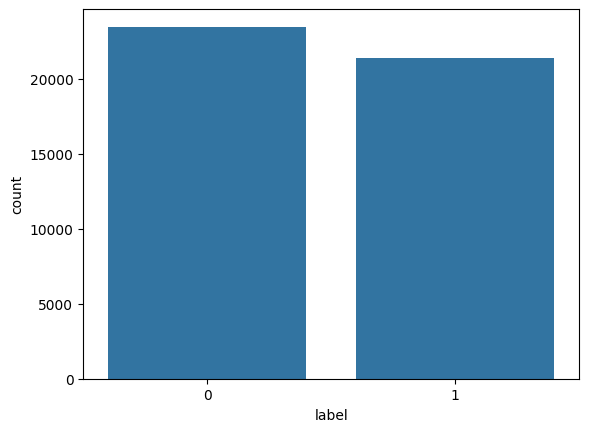

In [30]:
sns.countplot(x='label', data=df)